0.6264772702608614
0.6258676916940099
0.5968698318375456


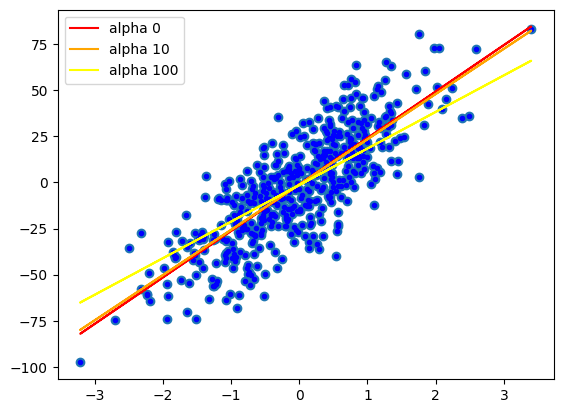

Coefficient: 24.506319184677626
Intercept: -1.2189937449928578


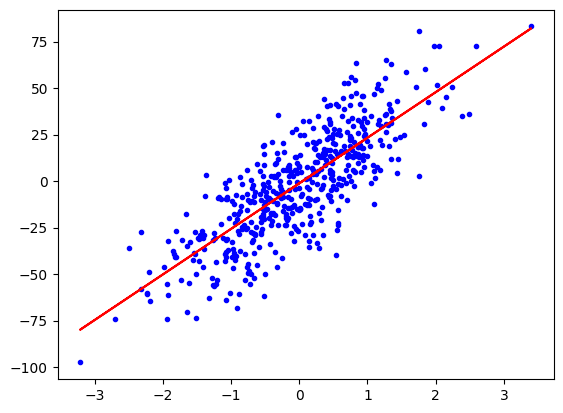

In [14]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge,LinearRegression
from sklearn.metrics import r2_score
from sklearn.datasets import make_regression

x,y = make_regression(n_features=1 ,n_samples=500,n_targets=1,noise=18,random_state=13) 

plt.scatter(x,y)

x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=10,test_size=0.15)

lr=LinearRegression()
lr.fit(x_train,y_train)

rid_10= Ridge(alpha=10)
rid_10.fit(x_train,y_train)

rid_100= Ridge(alpha=100)
rid_100.fit(x_train,y_train)

pred1 = lr.predict(x_test)
pred2 = rid_10.predict(x_test)
pred3 = rid_100.predict(x_test)

print(r2_score(y_test,pred1))
print(r2_score(y_test,pred2))
print(r2_score(y_test,pred3))


plt.plot(x,y,'b.')
plt.plot(x,lr.predict(x),color="red",label="alpha 0")
plt.plot(x,rid_10.predict(x),color="orange",label="alpha 10")
plt.plot(x,rid_100.predict(x),color="yellow",label="alpha 100")
plt.legend()
plt.show()


class meraLR:
    
    def __init__(self, alpha):
        self.coef_ = None
        self.intercept_ = None
        self.alpha = alpha
    
    def fit(self, x_train, y_train):
        
        x_train = np.array(x_train).reshape(-1)
        y_train = np.array(y_train)
        
        x_mean = x_train.mean()
        y_mean = y_train.mean()
        
        num = np.sum((y_train - y_mean) * (x_train - x_mean))
        den = np.sum((x_train - x_mean) ** 2)
        
        self.coef_ = num / (den + self.alpha)
        self.intercept_ = y_mean - (self.coef_ * x_mean)
        
        print("Coefficient:", self.coef_)
        print("Intercept:", self.intercept_)
    
    def predict(self, x_test):
        
        x_test = np.array(x_test).reshape(-1)
        
        return self.intercept_ + (self.coef_ * x_test)

RID = meraLR(alpha=10)

RID.fit(x_train,y_train),rid_10.coef_ ,rid_10.intercept_

pred4 = RID.predict(x_test)

r2_score(y_test,pred4)

plt.plot(x,y,"b.")
plt.plot(x,RID.predict(x),color="red")
plt.show()



In [15]:
RID = meraLR(alpha=10)

RID.fit(x_train,y_train),rid_10.coef_ ,rid_10.intercept_




Coefficient: 24.506319184677626
Intercept: -1.2189937449928578


(None, array([24.50631918]), np.float64(-1.2189937449928578))

In [29]:

class MeraRidge:
    
    def __init__(self,alpha=0.1):
        
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
        
    def fit(self,X_train,y_train):
        
        X_train = np.insert(X_train,0,1,axis=1)
        I = np.identity(X_train.shape[1])
        I[0][0] = 0
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha * I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    
    def predict(self,X_test):
        return np.dot(X_test,self.coef_) + self.intercept_    

In [30]:
x,y = make_regression(n_features=2 ,n_samples=500,n_targets=1,noise=18,random_state=13) 



x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=10,test_size=0.15)

lr=LinearRegression()
lr.fit(x_train,y_train)

rid_10= Ridge(alpha=10)
rid_10.fit(x_train,y_train)

rid_100= Ridge(alpha=100)
rid_100.fit(x_train,y_train)

pred1 = lr.predict(x_test)
pred2 = rid_10.predict(x_test)
pred3 = rid_100.predict(x_test)


print(r2_score(y_test,pred1))
print(r2_score(y_test,pred2))
print(r2_score(y_test,pred3))

0.9837649278012147
0.9826686910358112
0.9388005337961439


In [31]:
my_lr = MeraRidge(alpha=0.1)

In [32]:
my_lr.fit(x_train,y_train)

In [33]:
pred = my_lr.predict(x_test)

In [34]:
r2_score(y_test,pred)

0.9837599611292692